<hr style="border:2px solid #CC00FF;">

<!-- Contenedor ultra-compatible. Usamos 'height' en lugar de 'width' para lograr simetría visual -->
<p align="center">
    <a href="https://medellin.unal.edu.co" target="_blank">
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" height="75" alt="Logo UNAL">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://minaslap.net/?redirect=0" target="_blank">
        <img src="https://minaslap.net/pluginfile.php/1/core_admin/logo/0x200/1770226238/Logo%20MinasLAP-3%20%281%29.png" height="75" alt="Logo MinasLAP">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://micampus.unal.edu.co" target="_blank">
        <img src="https://micampus.unal.edu.co/pluginfile.php/1/theme_almondb/sliderimage1/1788871931/Slider_1.png" height="75" alt="Logo MiCampus">
    </a>
</p>

<!-- Títulos usando alineación clásica compatible con IDEs -->
<h1 align="center">Optimización e IA 2026-2S</h1>
<h2 align="center">Práctica 1</h2>
<h3 align="center">Parte 2: Gradiente Descendente</h3>
<p align="center">
    Departamento de Ciencias de la Computación y de la Decisión<br>
    Facultad de Minas<br>
    Universidad Nacional de Colombia<br>
    Docente: Maria Constanza Torres Madronero
</p>

<div id="conte"></div>
<hr style="border:2px solid #CC00FF;">

**Elaborado por:** _Kevin Ferney Hidalgo Higuita_

**Correo:** _kfhidalgoh@unal.edu.co_

**Fecha de elaboración:** _12 de septiembre de 2026_

**Fecha última modificación:** _12 de septiembre de 2026_

**Repositorio:** [![GitHub Repository](https://img.shields.io/badge/repository-GitHub-181717.svg)](https://github.com/KevinHidalgoDS/optimizacion-ia)

*Nota: el tema del navegador para visualizar HTML puede afectar el comportamiento de la presentación.*

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from src.utils import logger as log

logger = log.LOGGER
config = log.CONFIG
logger.info("Python %s on %s", sys.version, sys.platform)

%matplotlib inline
rng = np.random.default_rng(123)

2026-09-16 06:13:02 [INFO] Python 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)] on win32


Encuentre el valor mínimo de la función del numeral 3 – Parte 1 utilizando el algoritmo de gradiente descendente.

La función es: $f\left(x,y\right)=\left(x^{2}+y-11\right)^{2}+\left(x+y^{2}-7\right)^{2}\;para\:x,y\in\left[-5,5\right]$

In [5]:
def f_objetivo(x: float | np.ndarray, y: float | np.ndarray) -> float | np.ndarray:
    """Calcula la función de vectorizada.

    Esta función matemática se define como:
    f(x, y) = (x**2 + y - 11)**2 + (x + y**2 - 7)**2
    El dominio estándar de evaluación suele ser x, y ∈ [-5, 5].

    Args:
        x (float o numpy.ndarray): Coordenada o arreglo de coordenadas en el eje X.
        y (float o numpy.ndarray): Coordenada o arreglo de coordenadas en el eje Y.

    Returns:
        float o numpy.ndarray: El valor o arreglo de valores resultantes
        tras evaluar la función.
    """
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2


def analizar_himmelblau_simbolico():
    """Calcula las derivadas parciales y puntos críticos de la función de Himmelblau.

    Utiliza SymPy para definir la ecuación matemáticamente, derivarla con
    respecto a 'x' e 'y', y buscar sus puntos críticos (donde el gradiente es 0).

    Returns:
        tuple: Una tupla que contiene (función_original, df_dx, df_dy).
    """
    # 1. Definir los símbolos matemáticos
    x, y = sp.symbols('x y')

    # 2. Escribir la ecuación exacta
    f = (x**2 + y - 11)**2 + (x + y**2 - 7)**2

    # 3. Calcular las derivadas parciales (Gradiente)
    df_dx = sp.diff(f, x)
    df_dy = sp.diff(f, y)

    # 4. (Opcional) Expandir algebraicamente las derivadas para ver el polinomio final
    df_dx_expandida = sp.expand(df_dx)
    df_dy_expandida = sp.expand(df_dy)

    print("=" * 40)
    print("🧠 ANÁLISIS SIMBÓLICO")
    print("=" * 40)
    print(f"🔸 Función original f(x,y):\n   {f}\n")
    print(f"🔸 Derivada parcial respecto a X (df/dx):\n   {df_dx}")
    print(f"   Expandida: {df_dx_expandida}\n")
    print(f"🔸 Derivada parcial respecto a Y (df/dy):\n   {df_dy}")
    print(f"   Expandida: {df_dy_expandida}\n")

    return f, df_dx, df_dy

f_simbolica, derivada_x, derivada_y = analizar_himmelblau_simbolico()

def f_derivada(x: float | np.ndarray, y: float | np.ndarray) -> list:
    """Devuelve el vector gradiente [df/dx, df/dy]."""
    df_dx = 4*x*(x**2 + y - 11) + 2*x + 2*y**2 - 14
    df_dy = 2*x**2 + 4*y*(x + y**2 - 7) + 2*y - 22
    return [df_dx, df_dy]


🧠 ANÁLISIS SIMBÓLICO
🔸 Función original f(x,y):
   (x + y**2 - 7)**2 + (x**2 + y - 11)**2

🔸 Derivada parcial respecto a X (df/dx):
   4*x*(x**2 + y - 11) + 2*x + 2*y**2 - 14
   Expandida: 4*x**3 + 4*x*y - 42*x + 2*y**2 - 14

🔸 Derivada parcial respecto a Y (df/dy):
   2*x**2 + 4*y*(x + y**2 - 7) + 2*y - 22
   Expandida: 2*x**2 + 4*x*y + 4*y**3 - 26*y - 22



Algoritmo de gradiente descendente, se modifica respecto al de clase, ya que la función objetivo recibe dos parámetros y tenemos derivadas parciales

In [4]:
def gradient_descent_2d(objetivo, derivada: np.ndarray, bounds: np.ndarray, n_iter: int, step_size: float, my_flag: bool=False) -> list:
    """Ejecuta el algoritmo de descenso de gradiente sobre una función objetivo.

    El algoritmo parte de un punto inicial aleatorio dentro de los límites
    indicados por ``bounds``, y en cada iteración calcula el gradiente de la
    función objetivo, actualiza la solución y almacena la evaluación resultante.

    Args:
        objetivo (Callable[[numpy.ndarray], float]): Función objetivo a minimizar.
            Debe aceptar un arreglo de NumPy y devolver un escalar.
        derivada (Callable[[numpy.ndarray], numpy.ndarray]): Función que calcula
            el gradiente de ``objetivo`` en un punto dado.
        bounds (numpy.ndarray): Arreglo de forma ``(n_dim, 2)`` donde cada fila
            representa ``[min, max]`` para cada dimensión del espacio de búsqueda.
        n_iter (int): Número de iteraciones a ejecutar. Debe ser un entero positivo.
        step_size (float): Tamaño de paso (tasa de aprendizaje) aplicado al gradiente.
            Debe ser un valor positivo.
        my_flag (bool, optional): Si es ``True``, imprime el progreso de cada
            iteración por consola. Por defecto es ``False``.

    Returns:
        list[list]: Lista con dos elementos ``[solutions, scores]``:
            - ``solutions`` (list[numpy.ndarray]): Puntos visitados por iteración.
            - ``scores`` (list[float]): Valores de la función objetivo en cada punto.

    Raises:
        TypeError: Si ``objetivo`` o ``derivada`` no son invocables, o si
            ``bounds`` n[]n ``numpy.ndarray``.
        ValueError: Si ``n_iter`` no es un entero positivo, si ``step_size`` no es
            positivo, o si ``bounds`` no tiene forma ``(n_dim, 2)``.
        RuntimeError: Si ocurre un error inesperado durante la evaluación de la
            función objetivo o su derivada.
    """
    logger.info("Iniciando descenso de gradiente con %d iteraciones.", n_iter)

    # ------------------------------------------------------------------
    # 1. Validación de entradas
    # ------------------------------------------------------------------
    if not callable(objetivo):
        logger.error("El parámetro 'objetivo' no es invocable: %r", type(objetivo))
        raise TypeError("El parámetro 'objetivo' debe ser una función invocable.")

    if not callable(derivada):
        logger.error("El parámetro 'derivada' no es invocable: %r", type(derivada))
        raise TypeError("El parámetro 'derivada' debe ser una función invocable.")

    if not isinstance(bounds, np.ndarray):
        logger.error("El parámetro 'bounds' no es un numpy.ndarray: %r", type(bounds))
        raise TypeError("El parámetro 'bounds' debe ser un numpy.ndarray.")

    if bounds.ndim != 2 or bounds.shape[1] != 2:
        logger.error("Forma inválida para 'bounds': %s. Se esperaba (n_dim, 2).", bounds.shape)
        raise ValueError("El parámetro 'bounds' debe tener forma (n_dim, 2).")

    if not isinstance(n_iter, int) or n_iter <= 0:
        logger.error("Valor inválido para 'n_iter': %r. Debe ser un entero positivo.", n_iter)
        raise ValueError("El parámetro 'n_iter' debe ser un entero positivo.")

    if not isinstance(step_size, (int, float)) or step_size <= 0:
        logger.error("Valor inválido para 'step_size': %r. Debe ser positivo.", step_size)
        raise ValueError("El parámetro 'step_size' debe ser un valor numérico positivo.")

    # ------------------------------------------------------------------
    # 2. Inicialización de estructuras de almacenamiento
    # ------------------------------------------------------------------
    solutions, scores = [], []

    # ------------------------------------------------------------------
    # 3. Generación aleatoria del punto inicial dentro de los límites
    # ------------------------------------------------------------------
    try:
        solution = bounds[:, 0] + rng.random(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
        logger.debug("Punto inicial generado: %s", solution)
    except Exception as exc:  # pragma: no cover - protección defensiva
        logger.exception("Error al generar el punto inicial aleatorio.")
        raise RuntimeError("No fue posible generar el punto inicial.") from exc

    # ------------------------------------------------------------------
    # 4. Bucle principal del algoritmo iterativo
    # ------------------------------------------------------------------
    for i in range(n_iter):
        logger.debug("Iteración %d de %d.", i + 1, n_iter)

        try:
            # 4.0 Desempaquetamos la solución en x e y para pasarla a nuestras funciones
            x, y = solution[0], solution[1]
            # 4.1. Cálculo del gradiente en la solución actual
            gradiente = np.array(derivada(x, y))

            # 4.2. Actualización de la solución aplicando el tamaño de paso
            solution = solution - step_size * gradiente

            # 4.3. Evaluación de la nueva solución en la función objetivo
            solution_eval = objetivo(solution[0], solution[1])
        except Exception as exc:
            logger.error(
                "Error durante la iteración %d: %s", i, exc, exc_info=True
            )
            raise RuntimeError(
                f"Fallo en la iteración {i} del descenso de gradiente."
            ) from exc

        # 4.4. Almacenamiento de la solución y su evaluación
        solutions.append(list(solution))
        scores.append(solution_eval)

        # 4.5. Reporte opcional del progreso por consola
        if my_flag:
            logger.info(">%d f(%s) = %.5f", i, solution, solution_eval)
            print(">%d f(%s) = %.5f" % (i, solution, solution_eval))

    logger.info("Descenso de gradiente finalizado tras %d iteraciones.", n_iter)

    # ------------------------------------------------------------------
    # 5. Retorno de los resultados obtenidos
    # ------------------------------------------------------------------
    return [np.array(solutions), np.array(scores)]

Definimos los límites del dominio [-5, 5] para X y Y

In [14]:
limites_dominio = np.array([[-5.0, 5.0], [-5.0, 5.0]])

Número de iteraciones

In [7]:
n_iteraciones = 50

Longitud del paso

In [8]:
tasa_aprendizaje = 0.01

Ejecutamos la función

In [13]:
soluciones, scores = gradient_descent_2d(
    objetivo=f_objetivo,
    derivada=f_derivada,
    bounds=limites_dominio,
    n_iter=n_iteraciones,
    step_size=tasa_aprendizaje,
    my_flag=True
)

2026-09-16 07:16:18 [INFO] Iniciando descenso de gradiente con 50 iteraciones.
2026-09-16 07:16:18 [DEBUG] Punto inicial generado: [-3.24094099  3.12094507]
2026-09-16 07:16:18 [DEBUG] Iteración 1 de 50.
2026-09-16 07:16:18 [INFO] >0 f([-2.89067554  3.13095135]) = 0.24484
2026-09-16 07:16:18 [DEBUG] Iteración 2 de 50.
2026-09-16 07:16:18 [INFO] >1 f([-2.83261383  3.13221053]) = 0.02479
2026-09-16 07:16:18 [DEBUG] Iteración 3 de 50.
2026-09-16 07:16:18 [INFO] >2 f([-2.81451091  3.13183248]) = 0.00288
2026-09-16 07:16:18 [DEBUG] Iteración 4 de 50.
2026-09-16 07:16:18 [INFO] >3 f([-2.80838718  3.1315351 ]) = 0.00035
2026-09-16 07:16:18 [DEBUG] Iteración 5 de 50.
2026-09-16 07:16:18 [INFO] >4 f([-2.8062632  3.1313985]) = 0.00004
2026-09-16 07:16:18 [DEBUG] Iteración 6 de 50.
2026-09-16 07:16:18 [INFO] >5 f([-2.80552013  3.13134425]) = 0.00001
2026-09-16 07:16:18 [DEBUG] Iteración 7 de 50.
2026-09-16 07:16:18 [INFO] >6 f([-2.80525936  3.13132397]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Itera

>0 f([-2.89067554  3.13095135]) = 0.24484
>1 f([-2.83261383  3.13221053]) = 0.02479
>2 f([-2.81451091  3.13183248]) = 0.00288
>3 f([-2.80838718  3.1315351 ]) = 0.00035
>4 f([-2.8062632  3.1313985]) = 0.00004
>5 f([-2.80552013  3.13134425]) = 0.00001
>6 f([-2.80525936  3.13132397]) = 0.00000
>7 f([-2.80516775  3.1313166 ]) = 0.00000
>8 f([-2.80513555  3.13131396]) = 0.00000
>9 f([-2.80512423  3.13131303]) = 0.00000
>10 f([-2.80512025  3.1313127 ]) = 0.00000
>11 f([-2.80511885  3.13131258]) = 0.00000
>12 f([-2.80511835  3.13131254]) = 0.00000
>13 f([-2.80511818  3.13131253]) = 0.00000
>14 f([-2.80511812  3.13131252]) = 0.00000
>15 f([-2.8051181   3.13131252]) = 0.00000
>16 f([-2.80511809  3.13131252]) = 0.00000
>17 f([-2.80511809  3.13131252]) = 0.00000
>18 f([-2.80511809  3.13131252]) = 0.00000
>19 f([-2.80511809  3.13131252]) = 0.00000
>20 f([-2.80511809  3.13131252]) = 0.00000
>21 f([-2.80511809  3.13131252]) = 0.00000
>22 f([-2.80511809  3.13131252]) = 0.00000
>23 f([-2.80511809  3.1

2026-09-16 07:16:18 [DEBUG] Iteración 37 de 50.
2026-09-16 07:16:18 [INFO] >36 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 38 de 50.
2026-09-16 07:16:18 [INFO] >37 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 39 de 50.
2026-09-16 07:16:18 [INFO] >38 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 40 de 50.
2026-09-16 07:16:18 [INFO] >39 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 41 de 50.
2026-09-16 07:16:18 [INFO] >40 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 42 de 50.
2026-09-16 07:16:18 [INFO] >41 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 43 de 50.
2026-09-16 07:16:18 [INFO] >42 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 44 de 50.
2026-09-16 07:16:18 [INFO] >43 f([-2.80511809  3.13131252]) = 0.00000
2026-09-16 07:16:18 [DEBUG] Iteración 45 de 50.
2026-09-

>36 f([-2.80511809  3.13131252]) = 0.00000
>37 f([-2.80511809  3.13131252]) = 0.00000
>38 f([-2.80511809  3.13131252]) = 0.00000
>39 f([-2.80511809  3.13131252]) = 0.00000
>40 f([-2.80511809  3.13131252]) = 0.00000
>41 f([-2.80511809  3.13131252]) = 0.00000
>42 f([-2.80511809  3.13131252]) = 0.00000
>43 f([-2.80511809  3.13131252]) = 0.00000
>44 f([-2.80511809  3.13131252]) = 0.00000
>45 f([-2.80511809  3.13131252]) = 0.00000
>46 f([-2.80511809  3.13131252]) = 0.00000
>47 f([-2.80511809  3.13131252]) = 0.00000
>48 f([-2.80511809  3.13131252]) = 0.00000
>49 f([-2.80511809  3.13131252]) = 0.00000


Se crea una función reutilizable basándose en los gráficos usados en la parte 1

In [11]:
def graficar_ruta_optimizacion(funcion_objetivo, historial, limites, titulo="Ruta del Descenso del Gradiente"):
    """Dibuja el mapa de contorno y superpone la ruta de optimización.

    Args:
        funcion_objetivo (callable): Función a evaluar f(x, y).
        historial (numpy.ndarray): Matriz bidimensional con el historial de puntos [x, y].
        limites (numpy.ndarray): Matriz con los límites del dominio [[x_min, x_max], [y_min, y_max]].
        titulo (str): Título principal del gráfico.
    """
    # Extraer límites
    x_min, x_max = limites[0]
    y_min, y_max = limites[1]

    # 1. Crear el grid para el mapa de contorno
    x_grid = np.linspace(x_min, x_max, 200)
    y_grid = np.linspace(y_min, y_max, 200)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = funcion_objetivo(X, Y)

    # 2. Configurar la figura
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    # 3. Dibujar contornos (usamos una escala logarítmica para ver mejor los valles)
    niveles = np.logspace(0, 3, 30) - 1  # Ajuste específico para que Himmelblau se vea espectacular
    contorno_relleno = ax.contourf(X, Y, Z, levels=niveles, cmap='viridis', extend='max')
    ax.contour(X, Y, Z, levels=niveles, colors='black', linewidths=0.3, alpha=0.4)

    # Agregar barra de color
    fig.colorbar(contorno_relleno, ax=ax, label='Valor de la función f(x,y)')

    # ==========================================
    # 🌟 APLICANDO LOS DATOS DEL HISTORIAL
    # ==========================================
    # Extraemos X e Y de todas las filas
    x_ruta = historial[:, 0]
    y_ruta = historial[:, 1]

    # Dibujar la línea de la trayectoria (blanca punteada)
    ax.plot(x_ruta, y_ruta, color='white', linestyle='--', linewidth=1.5, alpha=0.8, zorder=3, label='Trayectoria')

    # Dibujar los puntos del Scatter plot
    ax.scatter(x_ruta, y_ruta, color='orange', edgecolors='black', s=40, zorder=4, label='Iteraciones')

    # Resaltar el inicio (Estrella verde gigante)
    ax.scatter(x_ruta[0], y_ruta[0], color='lime', edgecolors='black', marker='*', s=300, zorder=5, label='Inicio')

    # Resaltar el final (X roja gigante)
    ax.scatter(x_ruta[-1], y_ruta[-1], color='red', edgecolors='white', marker='X', s=150, zorder=5, label='Fin (Óptimo)')
    # ==========================================

    # Configurar formato final
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Eje X', fontsize=12)
    ax.set_ylabel('Eje Y', fontsize=12)
    ax.set_title(titulo, fontsize=14, pad=15)

    # Añadir leyenda en la esquina superior derecha
    ax.legend(loc='upper right', framealpha=0.9)

    fig.tight_layout()
    plt.show()

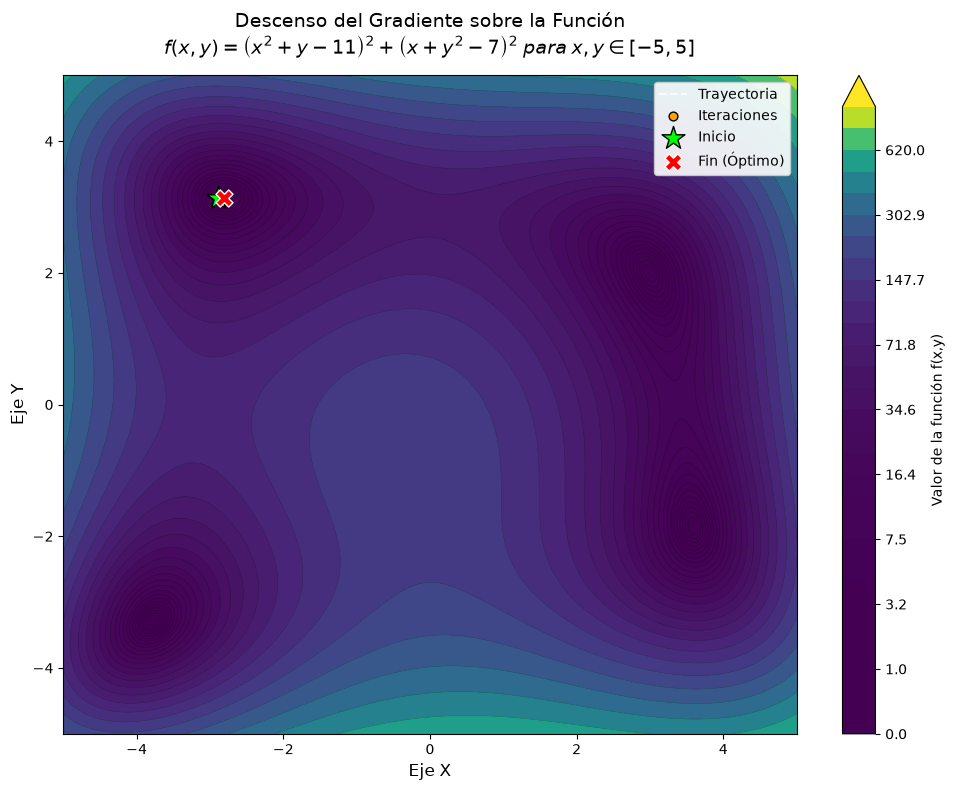

In [22]:
graficar_ruta_optimizacion(
        funcion_objetivo=f_objetivo,
        historial=soluciones,
        limites=limites_dominio,
        titulo=r"Descenso del Gradiente sobre la Función" "\n" r"$f\left(x,y\right)=\left(x^{2}+y-11\right)^{2}+\left(x+y^{2}-7\right)^{2}\;para\:x,y\in\left[-5,5\right]$"
    )